<a href="https://colab.research.google.com/github/Amary754/gaming-analysis/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("/vgsales.csv")
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [ ]:
import pandas as pd

df = pd.read_csv("/vgsales.csv")
df.info

<bound method DataFrame.info of         Rank                                              Name Platform  \
0          1                                        Wii Sports      Wii   
1          2                                 Super Mario Bros.      NES   
2          3                                    Mario Kart Wii      Wii   
3          4                                 Wii Sports Resort      Wii   
4          5                          Pokemon Red/Pokemon Blue       GB   
...      ...                                               ...      ...   
16593  16596                Woody Woodpecker in Crazy Castle 5      GBA   
16594  16597                     Men in Black II: Alien Escape       GC   
16595  16598  SCORE International Baja 1000: The Official Game      PS2   
16596  16599                                        Know How 2       DS   
16597  16600                                  Spirits & Spells      GBA   

         Year         Genre   Publisher  NA_Sales  EU_Sales  JP_Sales  \
0      2006.0        Sports    Nintendo     41.49     29.02      3.77   
1      1985.0      Platform    Nintendo     29.08      3.58      6.81   
2      2008.0        Racing    Nintendo     15.85     12.88      3.79   
3      2009.0        Sports    Nintendo     15.75     11.01      3.28   
4      1996.0  Role-Playing    Nintendo     11.27      8.89     10.22   
...       ...           ...         ...       ...       ...       ...   
16593  2002.0      Platform       Kemco      0.01      0.00      0.00   
16594  2003.0       Shooter  Infogrames      0.01      0.00      0.00   
16595  2008.0        Racing  Activision      0.00      0.00      0.00   
16596  2010.0        Puzzle    7G//AMES      0.00      0.01      0.00   
16597  2003.0      Platform     Wanadoo      0.01      0.00      0.00   

       Other_Sales  Global_Sales  
0             8.46         82.74  
1             0.77         40.24  
2             3.31         35.82  
3             2.96         33.00  
4             1.00         31.37  
...            ...           ...  
16593         0.00          0.01  
16594         0.00          0.01  
16595         0.00          0.01  
16596         0.00          0.01  
16597         0.00          0.01  

[16598 rows x 11 columns]>

In [ ]:
import pandas as pd

df = pd.read_csv("/vgsales.csv")
df.shape

(16598, 11)

In [ ]:
import pandas as pd

df = pd.read_csv("/vgsales.csv")
df_clean = df.copy()


In [ ]:
print("Duplicates:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()

Duplicates: 0


In [ ]:
df_clean = df_clean.dropna(subset=["Year", "Publisher"])

In [ ]:
df_clean["Year"] = df_clean["Year"].astype(int)

In [ ]:
for col in ["Name", "Platform", "Genre", "Publisher"]:
    df_clean[col] = df_clean[col].str.strip()

In [ ]:
print(df_clean["Year"].min(), df_clean["Year"].max())
print((df_clean["Global_Sales"] <= 0).sum())

1980 2020
0


In [ ]:
df_clean = df_clean.reset_index(drop=True)

In [ ]:
df_clean.isnull().sum()
print(df.shape, "->", df_clean.shape)

(16598, 11) -> (16291, 11)


In [ ]:
df_clean.to_csv("vgsales_clean.csv", index=False)

In [ ]:
df_clean.shape

(16291, 11)

## Cleaning Summary
- Original rows
- Duplicates removed
- Rows with missing Year/Publisher removed
- Year converted from decimal to integer
- Extra spaces removed from text columns


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

question 1: Which genres have the highest global sales?

In [ ]:
genre_sales = (df_clean.groupby("Genre")["Global_Sales"]
               .sum()
               .sort_values(ascending=False))
genre_sales

,Global_Sales
Genre,
Action,1722.84
Sports,1309.24
Shooter,1026.20
Role-Playing,923.83
Platform,829.13
Misc,789.87
Racing,726.76
Fighting,444.05
Simulation,389.98


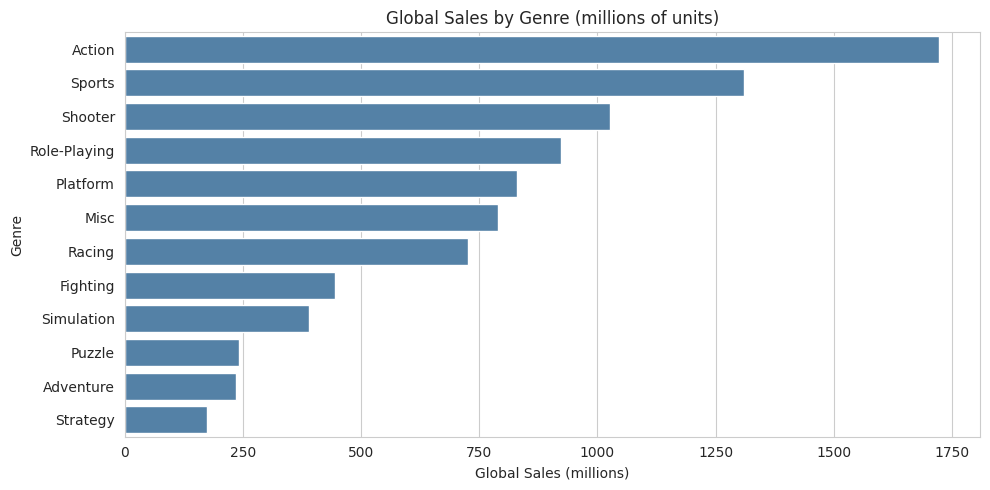

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x=genre_sales.values, y=genre_sales.index, color="steelblue")
plt.title("Global Sales by Genre (millions of units)")
plt.xlabel("Global Sales (millions)")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

Question 2: How have sales changed year by year?

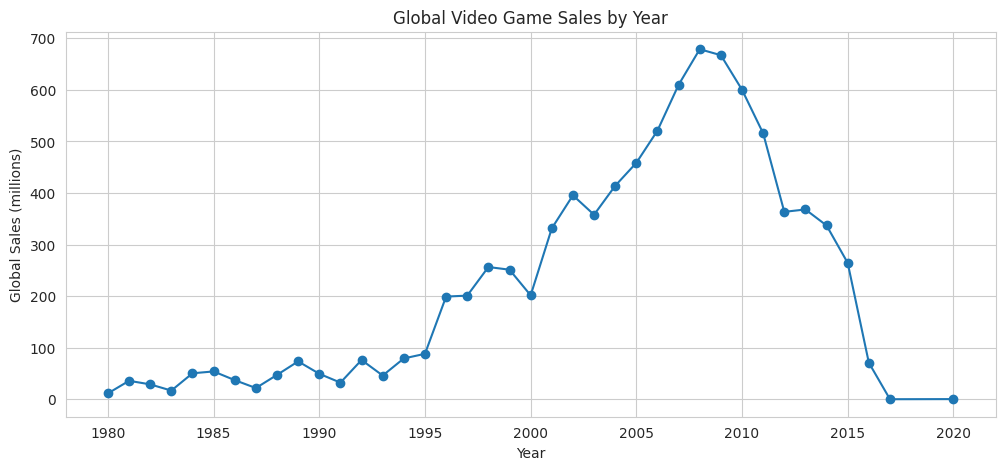

In [ ]:
yearly_sales = df_clean.groupby("Year")["Global_Sales"].sum()

plt.figure(figsize=(12, 5))
plt.plot(yearly_sales.index, yearly_sales.values, marker="o")
plt.title("Global Video Game Sales by Year")
plt.xlabel("Year")
plt.ylabel("Global Sales (millions)")
plt.show()

Question 3: Which platforms sell the most?

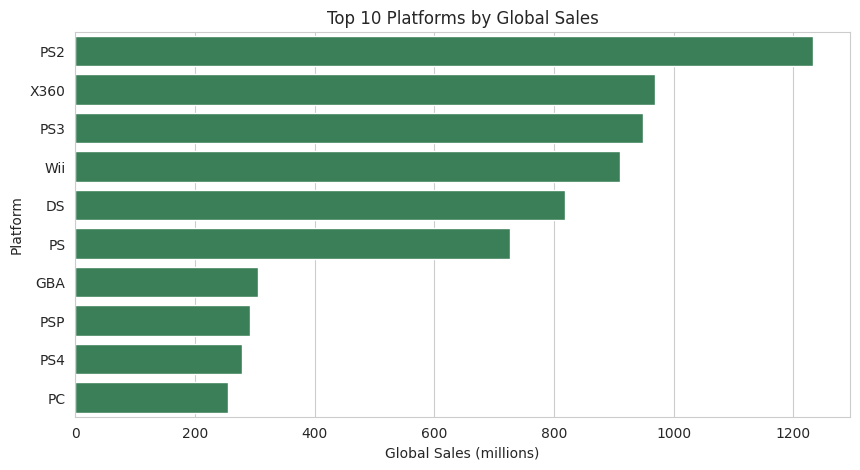

In [ ]:
platform_sales = (df_clean.groupby("Platform")["Global_Sales"]
                  .sum()
                  .sort_values(ascending=False)
                  .head(10))

plt.figure(figsize=(10, 5))
sns.barplot(x=platform_sales.values, y=platform_sales.index, color="seagreen")
plt.title("Top 10 Platforms by Global Sales")
plt.xlabel("Global Sales (millions)")
plt.show()

Question 4: Which publishers dominate?

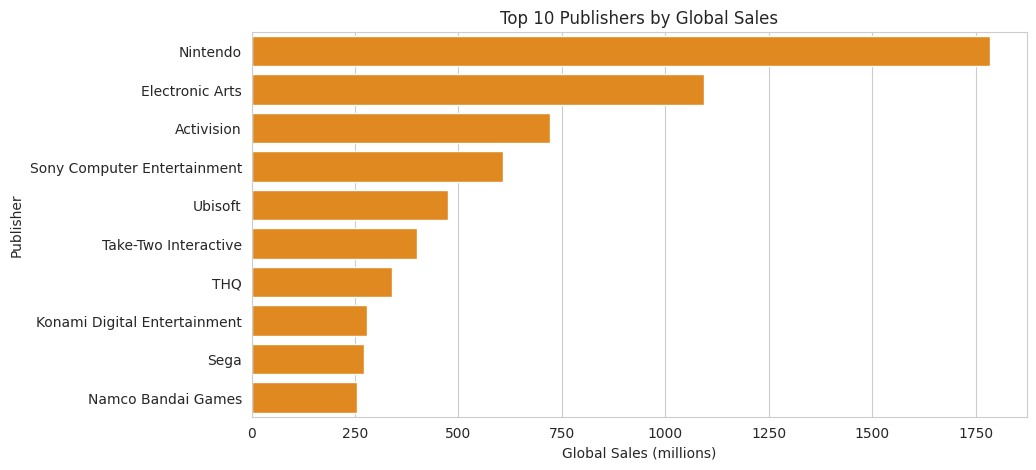

In [ ]:
publisher_sales = (df_clean.groupby("Publisher")["Global_Sales"]
                   .sum()
                   .sort_values(ascending=False)
                   .head(10))

plt.figure(figsize=(10, 5))
sns.barplot(x=publisher_sales.values, y=publisher_sales.index, color="darkorange")
plt.title("Top 10 Publishers by Global Sales")
plt.xlabel("Global Sales (millions)")
plt.show()

Question 5: Do regions prefer different genres?

In [ ]:
region_genre = df_clean.groupby("Genre")[["NA_Sales", "EU_Sales", "JP_Sales"]].sum()
region_genre

,NA_Sales,EU_Sales,JP_Sales
Genre,,,
Action,861.77,516.48,158.65
Adventure,101.93,63.74,51.99
Fighting,220.74,100.00,87.15
Misc,396.92,211.77,106.67
Platform,445.99,200.65,130.65
Puzzle,122.01,50.52,56.68
Racing,356.93,236.31,56.61
Role-Playing,326.50,187.57,350.29
Shooter,575.16,310.45,38.18


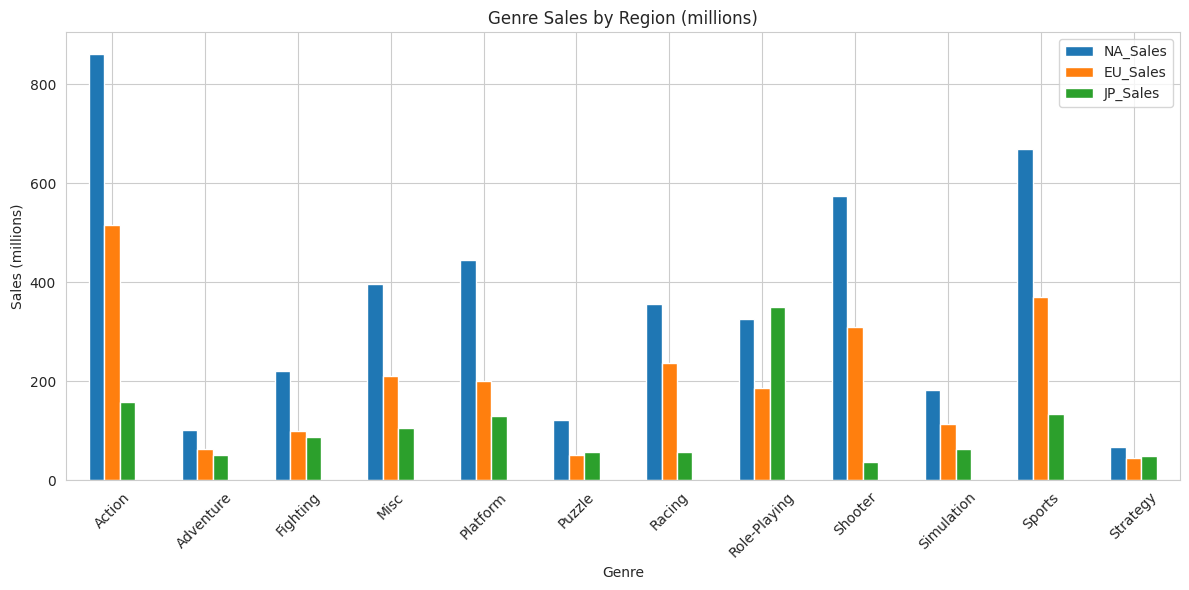

In [ ]:
region_genre.plot(kind="bar", figsize=(12, 6))
plt.title("Genre Sales by Region (millions)")
plt.ylabel("Sales (millions)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
region_pct = region_genre.div(region_genre.sum()) * 100
region_pct.round(1)

,NA_Sales,EU_Sales,JP_Sales
Genre,,,
Action,19.9,21.5,12.4
Adventure,2.4,2.6,4.0
Fighting,5.1,4.2,6.8
Misc,9.2,8.8,8.3
Platform,10.3,8.3,10.2
Puzzle,2.8,2.1,4.4
Racing,8.2,9.8,4.4
Role-Playing,7.5,7.8,27.3
Shooter,13.3,12.9,3.0


In [7]:
import matplotlib.pyplot as plt

plt.savefig("genre_sales.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>